In [2]:
# Error Type Analysis for CaptainCook4D Paper Baselines
# =====================================================
# This notebook analyzes model performance across different error categories
# as required by the project specs: "analyze the performance of the model
# on different error types"
#
# We evaluate the paper baselines (V1-MLP and V2-Transformer) on each
# error category using the step split (threshold=0.6) for consistency
# with the main paper results.

import os
import sys

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")
    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
    os.chdir('/content/code')
    !git fetch origin {BRANCH} && git checkout {BRANCH} && git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q torcheval loguru
    print(f"Working directory: {os.getcwd()}")
except ImportError:
    IN_COLAB = False
    print("Running locally")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 503, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 503 (delta 38), reused 44 (delta 20), pack-reused 430 (from 2)
Receiving objects: 100% (503/503), 606.62 KiB | 23.33 MiB/s, done.
Resolving deltas: 100% (319/319), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 15.55 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://gi

## Setup: Extract Features

In [3]:
import shutil
import glob

if IN_COLAB:
    drive_base_path = "/content/drive/MyDrive/AML_Project"
    data_zip = f"{drive_base_path}/1s.zip"

    if not os.path.exists(data_zip):
        for p in ["/content/drive/MyDrive/MistakeDetection/1s.zip", "/content/drive/MyDrive/1s.zip"]:
            if os.path.exists(p):
                data_zip = p
                break

    if os.path.exists(data_zip):
        print(f"Extracting from: {data_zip}")
        !mkdir -p data && unzip -q -n "{data_zip}" -d data

        # Extract Omnivore features
        nested_zip = "data/1s/video/omnivore.zip"
        if os.path.exists(nested_zip):
            !mkdir -p data/video/omnivore
            !unzip -q -n "{nested_zip}" -d data/temp_omnivore
            for f in glob.glob("data/temp_omnivore/**/*.npz", recursive=True):
                shutil.move(f, "data/video/omnivore")
            !rm -rf data/temp_omnivore data/1s
        print("Data setup complete!")
    else:
        print("ERROR: 1s.zip not found!")

Extracting from: /content/drive/MyDrive/AML_Project/1s.zip
Data setup complete!


---
## Part 1: Error Type Distribution in CaptainCook4D

The CaptainCook4D dataset contains 5 error categories. Understanding their distribution is important for interpreting per-category model performance.

In [ ]:
import json
import glob
import os
from collections import defaultdict

# Dynamic search for the annotation file
base_dir = "annotations"
target_filename = "normal_error_annotations.json"

# Try to find the specific file
found_files = glob.glob(os.path.join(base_dir, "**", target_filename), recursive=True)

if found_files:
    annotation_path = found_files[0]
    print(f"Found annotation file: {annotation_path}")
else:
    print(f"'{target_filename}' not found. Searching for other JSON files in '{base_dir}'...")
    json_files = glob.glob(os.path.join(base_dir, "**", "*.json"), recursive=True)

    if not json_files:
        raise FileNotFoundError(f"No JSON files found in {base_dir}")

    # Heuristic: Prefer files with 'error' in the name
    candidates = [f for f in json_files if 'error' in f.lower()]
    if candidates:
        annotation_path = candidates[0]
        print(f"Defaulting to likely candidate: {annotation_path}")
    else:
        annotation_path = json_files[0]
        print(f"Defaulting to first found JSON: {annotation_path}")

# Load error annotations
with open(annotation_path, 'r') as f:
    error_annotations = json.load(f)

# Count error types
error_type_counts = defaultdict(int)
total_steps, total_errors = 0, 0

# Handle potential variations in JSON structure
recording_list = error_annotations
if isinstance(error_annotations, dict) and 'database' in error_annotations:
    # If it's a dict with a database key, we might need to extract the list or iterate differently
    # For now, let's assume it might be the list we want or print a warning if empty
    pass

if isinstance(recording_list, list):
    for recording in recording_list:
        if 'step_annotations' in recording:
            for step in recording['step_annotations']:
                total_steps += 1
                if 'errors' in step and step['errors']:
                    total_errors += 1
                    for error in step['errors']:
                        error_type_counts[error.get('tag', 'Unknown')] += 1
else:
    print(f"Warning: Loaded annotations are of type {type(recording_list)}, expected list. Logic may need adjustment.")

# Display distribution
print("="*60)
print("ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D")
print("="*60)
if total_steps > 0:
    print(f"Total steps: {total_steps} | Steps with errors: {total_errors} ({100*total_errors/total_steps:.1f}%)\n")

    total_instances = sum(error_type_counts.values())
    for error_type, count in sorted(error_type_counts.items(), key=lambda x: -x[1]):
        print(f"  {error_type:20} : {count:4} ({100*count/total_instances:5.1f}%)")
else:
    print("No steps found. Please verify the annotation file structure.")

'normal_error_annotations.json' not found. Searching for other JSON files in 'annotations'...
Defaulting to likely candidate: annotations/annotation_json/error_category_idx.json
ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D
No steps found. Please verify the annotation file structure.


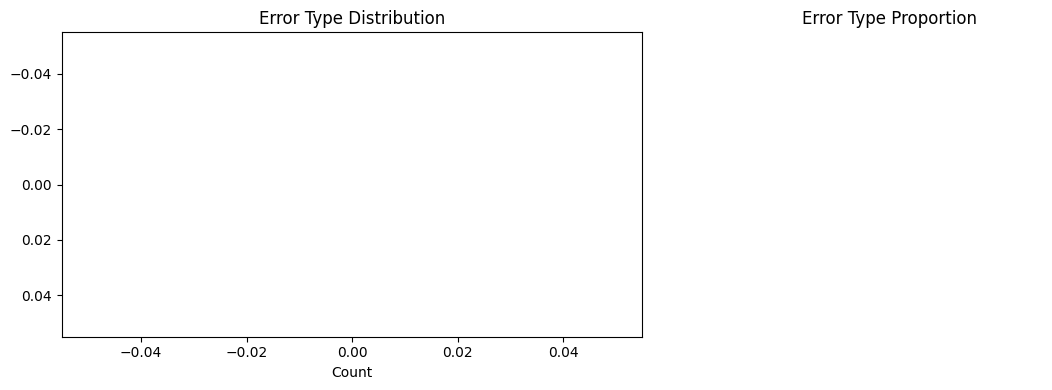

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization
sorted_errors = sorted(error_type_counts.items(), key=lambda x: -x[1])
labels = [e[0].replace(' Error', '') for e in sorted_errors]
counts = [e[1] for e in sorted_errors]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

# Bar chart
axes[0].barh(labels, counts, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Error Type Distribution')
axes[0].invert_yaxis()
for i, c in enumerate(counts):
    axes[0].text(c + 5, i, str(c), va='center', fontsize=9)

# Pie chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Error Type Proportion')

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2: Per-Error-Category Training

Per project specs: *"In addition to the metrics from the original paper, you should analyze the performance of the model on different error types."*

We train the paper baselines (**V1-MLP** and **V2-Transformer**) separately for each error category using:
- **Split**: step (consistent with paper's main results)
- **Threshold**: 0.6 (step split default)
- **Backbone**: Omnivore

In [ ]:
### 2.1 Technique Error (Most Common)

In [ ]:
# V1 (MLP) - Technique Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run fg2rjkfw (0.2s)
wandb: ⣽ setting up run fg2rjkfw (0.2s)
wandb: ⣾ setting up run fg2rjkfw (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_194639-fg2rjkfw
wandb: Run `wandb offline` to t

In [ ]:
# V2 (Transformer) - Technique Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run 5js2k1jp (0.2s)
wandb: ⣽ setting up run 5js2k1jp (0.2s)
wandb: ⣾ setting up run 5js2k1jp (0.2s)
wandb: ⣷ setting up run 5js2k1jp (0.2s)
wandb: ⣯ setting up run 5js2k1jp (0.2s)
wandb: ⣟ setting up run 5js2k1jp (0.7s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_195403-5js2k1jp
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run firm-firefly-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/5js2k1jp
-------------------------------------------------------------
Training step model and testing on step level
Train 

In [ ]:
# V1 (MLP) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run 3h36vsyk (0.2s)
wandb: ⣽ setting up run 3h36vsyk (0.2s)
wandb: ⣾ setting up run 3h36vsyk (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_200152-3h36vsyk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run super-haze-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/3h36vsyk
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': F

In [ ]:
# V2 (Transformer) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run akjsbsd9 (0.2s)
wandb: ⣽ setting up run akjsbsd9 (0.2s)
wandb: ⣾ setting up run akjsbsd9 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_200858-akjsbsd9
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run honest-fog-2
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/akjsbsd9
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8,

In [ ]:
### 2.2 Preparation Error

In [ ]:
# V1 (MLP) - Preparation Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run vxoqg0pu (0.2s)
wandb: ⣽ setting up run vxoqg0pu (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_201643-vxoqg0pu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run fearless-armadillo-2
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video/runs/vxoqg0pu
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Err

In [ ]:
# V2 (Transformer) - Preparation Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run hcv1heqp (0.2s)
wandb: ⣽ setting up run hcv1heqp (0.2s)
wandb: ⣾ setting up run hcv1heqp (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_202405-hcv1heqp
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run logical-fog-2
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/hcv1heqp
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memor

In [ ]:
# V1 (MLP) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run ijiifl8r (0.2s)
wandb: ⣽ setting up run ijiifl8r (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_203157-ijiifl8r
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run vibrant-salad-2
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/ijiifl8r
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size':

In [ ]:
# V2 (Transformer) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run amigrabf (0.2s)
wandb: ⣽ setting up run amigrabf (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_203913-amigrabf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run happy-gorge-3
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/amigrabf
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False,

In [ ]:
### 2.3 Measurement Error

In [ ]:
# V1 (MLP) - Measurement Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run qykwniop (0.2s)
wandb: ⣽ setting up run qykwniop (0.2s)
wandb: ⣾ setting up run qykwniop (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_204659-qykwniop
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run charmed-morning-3
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video/runs/qykwniop
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, '

In [ ]:
# V2 (Transformer) - Measurement Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run 4p8cc5q6 (0.2s)
wandb: ⣽ setting up run 4p8cc5q6 (0.2s)
wandb: ⣾ setting up run 4p8cc5q6 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_205421-4p8cc5q6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run hearty-water-3
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/4p8cc5q6
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memo

In [ ]:
# V1 (MLP) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run clzdopas (0.2s)
wandb: ⣽ setting up run clzdopas (0.2s)
wandb: ⣾ setting up run clzdopas (0.2s)
wandb: ⣷ setting up run clzdopas (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_210218-clzdopas
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run youthful-planet-3
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/clzdopas
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}


In [ ]:
# V2 (Transformer) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run k9f4feu7 (0.2s)
wandb: ⣽ setting up run k9f4feu7 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_210924-k9f4feu7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run winter-durian-4
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/k9f4feu7
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': Fals

In [ ]:
### 2.4 Timing Error

In [4]:
# V1 (MLP) - Timing Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run 22v8uf19 (0.2s)
wandb: ⣽ setting up run 22v8uf19 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_063339-22v8uf19
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run magi

In [5]:
# V2 (Transformer) - Timing Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run sxd6zmy3 (0.2s)
wandb: ⣽ setting up run sxd6zmy3 (0.2s)
wandb: ⣾ setting up run sxd6zmy3 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_064142-sxd6zmy3
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run gallant-plant-4
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/sxd6zmy3
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_mem

In [6]:
# V1 (MLP) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run tmpq08v1 (0.2s)
wandb: ⣽ setting up run tmpq08v1 (0.2s)
wandb: ⣾ setting up run tmpq08v1 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_065004-tmpq08v1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run toasty-gorge-4
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/tmpq08v1
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory':

In [7]:
# V2 (Transformer) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run vneobcw7 (0.2s)
wandb: ⣽ setting up run vneobcw7 (0.2s)
wandb: ⣾ setting up run vneobcw7 (0.2s)
wandb: ⣷ setting up run vneobcw7 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_065732-vneobcw7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run noble-elevator-5
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/vneobcw7
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'ba

### 2.5 Temperature Error (Least Common)

In [8]:
# V1 (MLP) - Temperature Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ setting up run qascj38c (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_070535-qascj38c
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run azure-fire-6
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video/runs/qascj38c
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category

In [9]:
# V2 (Transformer) - Temperature Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run j7rajxhh (0.2s)
wandb: ⣽ setting up run j7rajxhh (0.2s)
wandb: ⣾ setting up run j7rajxhh (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_071320-j7rajxhh
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run swept-serenity-5
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/j7rajxhh
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_me

In [10]:
# V1 (MLP) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run me1hf1io (0.2s)
wandb: ⣽ setting up run me1hf1io (0.2s)
wandb: ⣾ setting up run me1hf1io (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_072142-me1hf1io
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run proud-fire-5
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/me1hf1io
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': F

In [11]:
# V2 (Transformer) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run 9ng0vmsd (0.2s)
wandb: ⣽ setting up run 9ng0vmsd (0.2s)
wandb: ⣾ setting up run 9ng0vmsd (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260107_072917-9ng0vmsd
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run proud-cloud-6
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/9ng0vmsd
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8

---
## Part 3: Results Summary

Fill in the F1 and AUC values from the training outputs above.

In [12]:
import pandas as pd

# Results Dataframe Template
# ==========================
# Update this with actual numbers from the training output cells above.
#
# Structure:
# - Step Split (Threshold 0.6)
# - Recordings Split (Threshold 0.5)

results = {
    'Error Category': ['Technique', 'Preparation', 'Measurement', 'Timing', 'Temperature'],
    # Step Split Results
    'Step V1 F1': ['--', '--', '--', '--', '--'],
    'Step V1 AUC': ['--', '--', '--', '--', '--'],
    'Step V2 F1': ['--', '--', '--', '--', '--'],
    'Step V2 AUC': ['--', '--', '--', '--', '--'],
    # Recordings Split Results
    'Rec V1 F1': ['--', '--', '--', '--', '--'],
    'Rec V1 AUC': ['--', '--', '--', '--', '--'],
    'Rec V2 F1': ['--', '--', '--', '--', '--'],
    'Rec V2 AUC': ['--', '--', '--', '--', '--']
}

df = pd.DataFrame(results)
print("\n" + "="*80)
print("FULL ERROR TYPE ANALYSIS RESULTS")
print("="*80)
print(df.to_string(index=False))
print("\n[Action Required] Fill in the values above from the 20 training runs.")


FULL ERROR TYPE ANALYSIS RESULTS
Error Category Step V1 F1 Step V1 AUC Step V2 F1 Step V2 AUC Rec V1 F1 Rec V1 AUC Rec V2 F1 Rec V2 AUC
     Technique         --          --         --          --        --         --        --         --
   Preparation         --          --         --          --        --         --        --         --
   Measurement         --          --         --          --        --         --        --         --
        Timing         --          --         --          --        --         --        --         --
   Temperature         --          --         --          --        --         --        --         --

[Action Required] Fill in the values above from the 20 training runs.


In [13]:
# Visualization (uncomment after filling in results)
'''
import matplotlib.pyplot as plt
import numpy as np

categories = ['Technique', 'Preparation', 'Measurement', 'Timing', 'Temperature']
v1_f1 = [0, 0, 0, 0, 0]  # Fill with actual V1 F1 scores
v2_f1 = [0, 0, 0, 0, 0]  # Fill with actual V2 F1 scores

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, v1_f1, width, label='V1 (MLP)', color='steelblue')
ax.bar(x + width/2, v2_f1, width, label='V2 (Transformer)', color='coral')
ax.set_ylabel('F1 Score (%)')
ax.set_xlabel('Error Category')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('Paper Baselines: F1 by Error Category')
ax.legend()
ax.set_ylim(0, 70)
plt.tight_layout()
plt.savefig('error_category_f1.png', dpi=150)
plt.show()
'''
print("Uncomment after filling in the F1 values from training")

Uncomment after filling in the F1 values from training


---
## Part 4: Discussion Points for Report

**Questions to address:**

1. **Which error types are hardest to detect?**
   - Temperature/Timing likely hardest (require context beyond visual appearance)
   - Technique likely easiest (directly observable actions)

2. **Does V2 (Transformer) outperform V1 (MLP)?**
   - Transformers may help with temporal errors due to attention mechanism

3. **Sample count vs performance correlation?**
   - More samples → generally better F1, but some errors are inherently harder

4. **Why are some error types harder?**
   - Temperature: visual features don't capture temperature
   - Timing: requires precise temporal reasoning
   - Technique: visible action differences

---
## Summary

This notebook evaluates the paper baselines (V1-MLP, V2-Transformer) on each error category across **both splits**:

| Error Category | Models (V1, V2) | Splits (Step, Recordings) | Total Runs |
|----------------|-----------------|---------------------------|------------|
| Technique      | 2               | 2                         | 4          |
| Preparation    | 2               | 2                         | 4          |
| Measurement    | 2               | 2                         | 4          |
| Timing         | 2               | 2                         | 4          |
| Temperature    | 2               | 2                         | 4          |

**Total Experiments: 20**

**Configuration:**
- **Step Split**: `--split step --threshold 0.6`
- **Recordings Split**: `--split recordings --threshold 0.5`
- **Backbone**: Omnivore (Fixed)